In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv('/content/weight-height.csv')

In [93]:
df.sample(5)

,Gender,Height,Weight
5732,Female,56.078700,94.488374
1731,Male,66.398128,170.217451
4512,Male,69.012028,182.686684
8550,Female,60.483946,110.565497
140,Male,68.860090,169.556821


In [94]:
df.shape

(10000, 3)

In [95]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Count'>

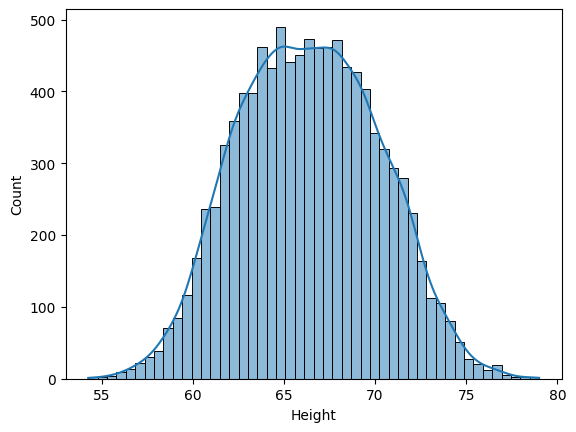

In [96]:
sns.histplot(df['Height'],kde=True)

<Axes: xlabel='Height'>

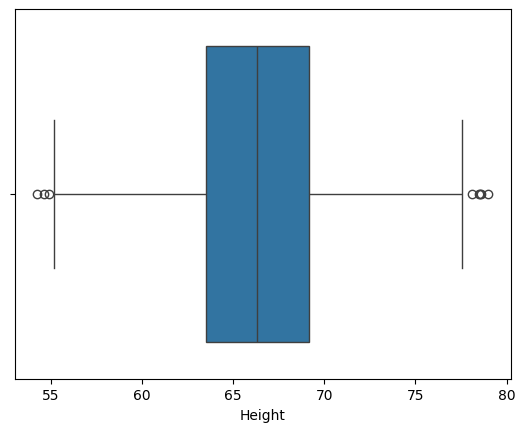

In [97]:
sns.boxplot(df['Height'],orient='h')

In [102]:
upper_limit=df['Height'].quantile(0.99)
lower_limit=df['Height'].quantile(0.01)

In [103]:
upper_limit,lower_limit

(np.float64(74.7857900583366), np.float64(58.13441158671655))

In [107]:
df[(df['Height'] > upper_limit) | (df['Height'] <lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# **Trimming**

In [108]:
new_df=df[(df['Height'] < upper_limit) & (df['Height']  > lower_limit)]

In [113]:
new_df.shape,df.shape

((9800, 3), (10000, 3))

In [114]:
new_df.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


<Axes: xlabel='Height', ylabel='Count'>

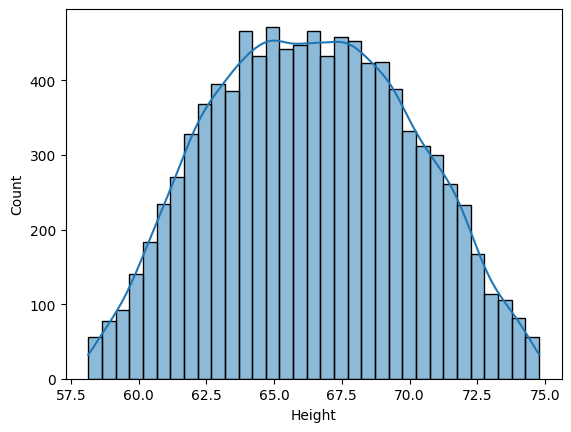

In [117]:
sns.histplot(new_df['Height'],kde=True)

<Axes: ylabel='Height'>

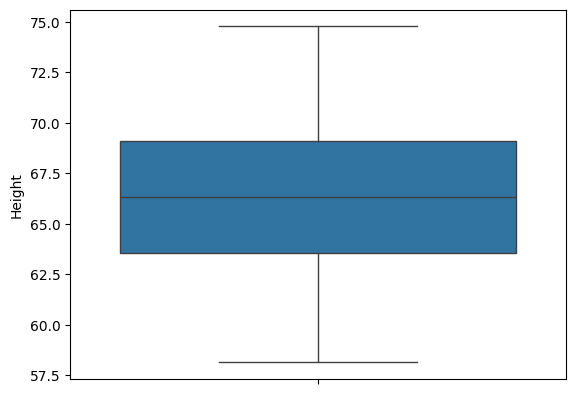

In [120]:
sns.boxplot(new_df['Height'])

#**Capping**

In [123]:
new_df_cap=df.copy()

new_df_cap['Height']=np.where(
    new_df_cap['Height'] > upper_limit,
    upper_limit,
    np.where(
      new_df_cap['Height'] < lower_limit,
      lower_limit,
      new_df_cap['Height']
    )
)

<Axes: xlabel='Height', ylabel='Count'>

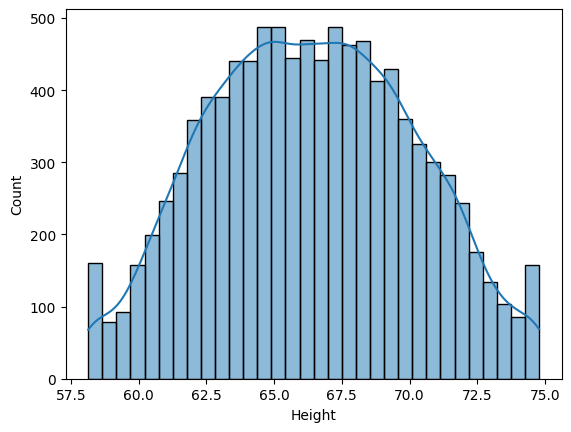

In [124]:
sns.histplot(new_df_cap['Height'],kde=True)

<Axes: ylabel='Height'>

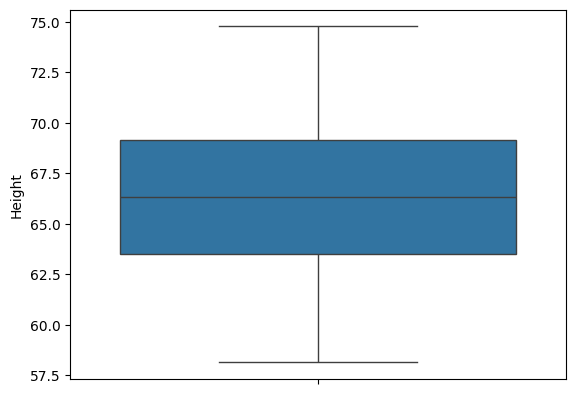

In [125]:
sns.boxplot(new_df_cap['Height'])

In [126]:
new_df_cap['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790
